# 04 — Index B (Steady-State)

**Objetivo.** Resolver Index_B con el menor RMSE de backtest a 252 días, eligiendo entre el baseline plano y una NN ligera, decidido por backtest (nunca por el loss de entrenamiento).

**Pistas del enunciado.** Steady-State defensivo: volatilidad moderada (~12.6% anual), precios grandes (~490k), serie estable con deriva suave.

**Estrategia.** Diagnóstico → suelo del baseline → LSTM en log-rets + backtest → ensemble 3 seeds solo si la LSTM ya gana → guardado condicional. Si gana el baseline, `model_path = None` y el notebook 09 lo reconstruye solo.

## 0. GPU workaround + imports + OWNER

El `CUDA_VISIBLE_DEVICES = "-1"` fuerza CPU-only y **debe ir antes de importar TensorFlow**: tu RTX 5070 Ti (Blackwell) no es compatible con el soporte GPU de TF y, sin esta línea, el import se cuelga indefinidamente. Importamos todo desde `utils.py` para usar las mismas funciones y constantes que el resto del equipo.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"   # CPU-only (RTX 5070 Ti Blackwell). ANTES de importar TF.

OWNER = "dani"        # <-- tu nombre, una sola vez
IDX   = "Index_B"

import json
import numpy as np
import matplotlib.pyplot as plt

from utils import (
    load_hackathon_data, make_temporal_split, make_window_dataset,
    baseline_flat, baseline_drift, baseline_random_walk,
    build_model, train_model, train_ensemble,
    backtest_autoregressive, plot_history, plot_rollout,
    DATA_DIR, VAL_DAYS, V_IN_SHARED, RANDOM_SEED,
)

os.makedirs("models",  exist_ok=True)
os.makedirs("results", exist_ok=True)
MODEL_PATH = f"models/{OWNER}_{IDX}.keras"

## 1. Carga y diagnóstico de Index_B

Antes de modelar miramos la forma de la serie, su volatilidad anual y su deriva reciente. Una serie defensiva tendrá un perfil suave y poca deriva en el último año, lo que sugiere que un baseline plano puede ser difícil de batir. El gráfico de log-retornos confirma visualmente si hay tramos de ruido extremo que una NN podría sobreajustar.

  [OK] train_indices.csv                   11956 filas x 6 cols  (1985-06-24 -> 2028-12-12)
  [OK] train_news.csv                      57393 filas x 3 cols  (1986-05-17 -> 2012-02-28)
  [OK] test_news.csv                        1205 filas x 3 cols  (2029-07-30 -> 2029-04-21)
  [OK] train_macro_factors.csv             10905 filas x 3 cols  (1985-06-24 -> 2028-12-12)
  [OK] test_macro_factors.csv                173 filas x 3 cols  (2028-12-13 -> 2029-08-21)
  [OK] train_network_metrics.csv           11956 filas x 2 cols  (1985-06-24 -> 2028-12-12)
  [OK] test_network_metrics.csv              252 filas x 2 cols  (2028-12-13 -> 2029-08-21)
Index_B: 11956 días
  min=865  max=529,857  último=492,687
  volatilidad anual (último año) ~ 12.6%
  deriva último año              ~ +13.5%


C:\Users\danie\AppData\Local\Temp\ipykernel_12692\1893764567.py:1: UserWarning: [load_hackathon_data] No encontrado: data/test_dates.csv
  data  = load_hackathon_data(DATA_DIR)


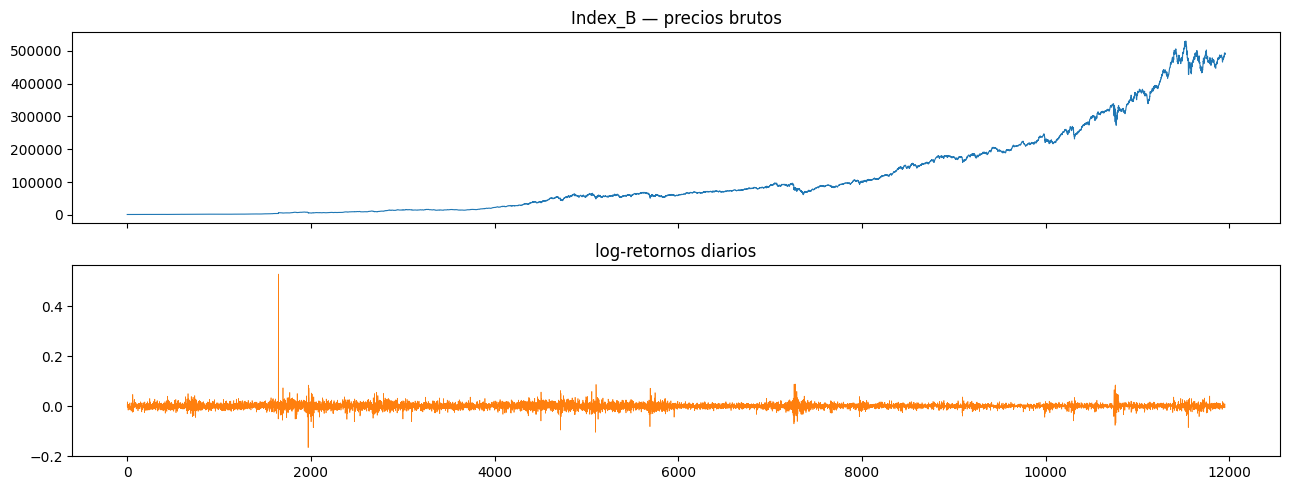

In [2]:
data  = load_hackathon_data(DATA_DIR)
idx   = data["train_indices"]
serie = idx[IDX].dropna().values

log_rets   = np.diff(np.log(serie))
vol_anual  = log_rets[-252:].std() * np.sqrt(252)   # volatilidad del último año
drift_rec  = (serie[-1] / serie[-252] - 1)          # deriva del último año

print(f"{IDX}: {len(serie)} días")
print(f"  min={serie.min():,.0f}  max={serie.max():,.0f}  último={serie[-1]:,.0f}")
print(f"  volatilidad anual (último año) ~ {vol_anual:.1%}")
print(f"  deriva último año              ~ {drift_rec:+.1%}")

fig, ax = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
ax[0].plot(serie, lw=0.8);                 ax[0].set_title(f"{IDX} — precios brutos")
ax[1].plot(log_rets, lw=0.5, color="tab:orange"); ax[1].set_title("log-retornos diarios")
plt.tight_layout(); plt.show()

## 2. Referencia: RMSE de baselines para B

Cargamos los baselines ya calculados en el notebook 01. Este es el **suelo a batir**: si ninguna NN lo supera en backtest, el baseline gana, y para una serie defensiva eso es un resultado perfectamente válido (más simple y sin riesgo de divergencia en el rollout largo).

In [3]:
with open("results/baselines.json") as f:
    baselines = json.load(f)

print(f"Baselines para {IDX}:")
for bl, rmse in baselines[IDX].items():
    print(f"  {bl:<15} RMSE = {rmse:,.0f}")

best_bl   = min(baselines[IDX], key=baselines[IDX].get)
best_rmse = baselines[IDX][best_bl]
print(f"\nMejor baseline: {best_bl}  ->  RMSE = {best_rmse:,.0f}  (SUELO A BATIR)")

Baselines para Index_B:
  flat            RMSE = 31,852
  drift           RMSE = 49,168
  random_walk     RMSE = 118,916

Mejor baseline: flat  ->  RMSE = 31,852  (SUELO A BATIR)


## 3. Confirmación visual del rollout del mejor baseline

El RMSE es un número; el gráfico nos dice *por qué*. Visualizamos cómo se comporta el mejor baseline sobre los 252 días reservados de validación, para confirmar que la forma de la predicción es razonable y no hay sorpresas (por ejemplo, un drift que se dispara).

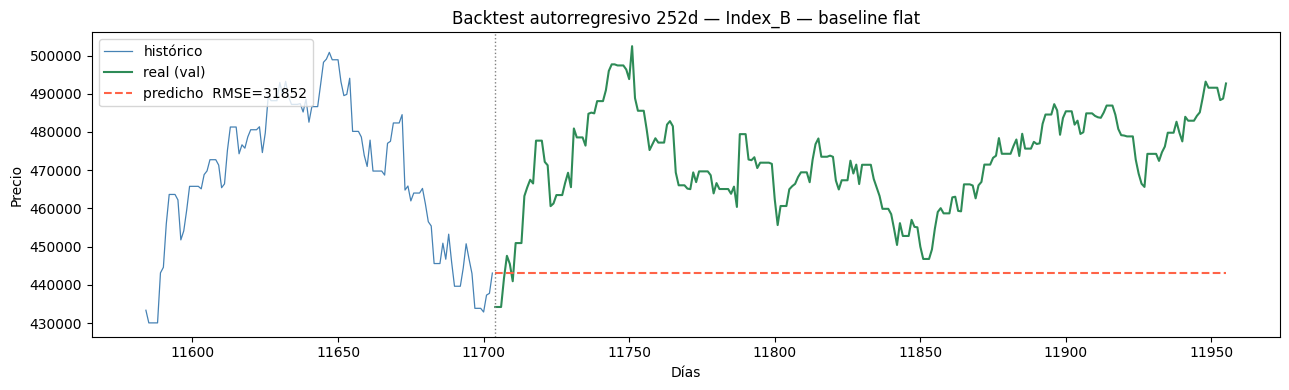

In [4]:
serie_train, _ = make_temporal_split(serie, val_days=VAL_DAYS, v_in=V_IN_SHARED)

_bl_fn = {"flat": baseline_flat, "drift": baseline_drift, "random_walk": baseline_random_walk}
preds_bl = _bl_fn[best_bl](serie_train, VAL_DAYS)

plot_rollout(serie, preds_bl, index_name=f"{IDX} — baseline {best_bl}", val_days=VAL_DAYS)

## 4. Candidato NN — LSTM en log-ret mode

Entrenamos en **log-retornos** (escala ~0.01, universal y numéricamente estable) en lugar de precios crudos (~490k, que desestabilizan el entrenamiento). La LSTM es la arquitectura natural para un rollout autorregresivo. Añadimos `dropout=0.2` para que no sobreajuste el ruido diario y diverja durante los 252 pasos. El split 80/20 interno solo sirve para que los callbacks tengan `val_loss`.

X_tr=(9346, 20, 1)  X_v=(2337, 20, 1)  n_features=1


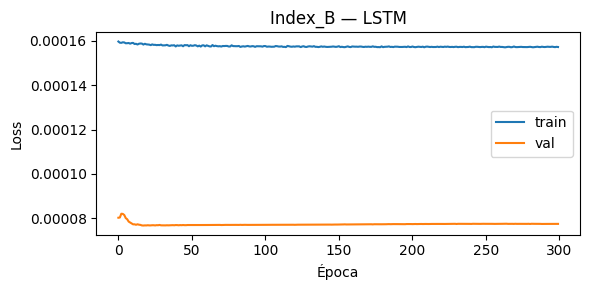

In [5]:
import tensorflow as tf
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Dataset de ventanas sobre el tramo de entrenamiento (sin tocar los últimos VAL_DAYS)
X, y = make_window_dataset(serie_train, V_IN_SHARED, use_log_rets=True)
cut  = int(len(X) * 0.8)
X_tr, y_tr = X[:cut], y[:cut]
X_v,  y_v  = X[cut:], y[cut:]
print(f"X_tr={X_tr.shape}  X_v={X_v.shape}  n_features={X.shape[2]}")

model_lstm = build_model("lstm", V_IN_SHARED, n_features=X.shape[2], units=64, dropout=0.2)
hist_lstm  = train_model(model_lstm, X_tr, y_tr, X_v, y_v, epochs=300)
plot_history(hist_lstm, title=f"{IDX} — LSTM")

### 4.1 Backtest LSTM a 252 días

**Este número — no el loss de entrenamiento — decide.** Un loss bajo en validación de 1 paso no predice el RMSE del rollout de 252 días, porque en el rollout el error se acumula al realimentar cada predicción. Comparamos el RMSE de backtest de la LSTM directamente contra el suelo del baseline.

LSTM      RMSE backtest = 27,182  |  dir_acc = 34.26%
baseline  RMSE backtest = 31,852  (flat)

✓ LSTM MEJORA el baseline (+14.7%)


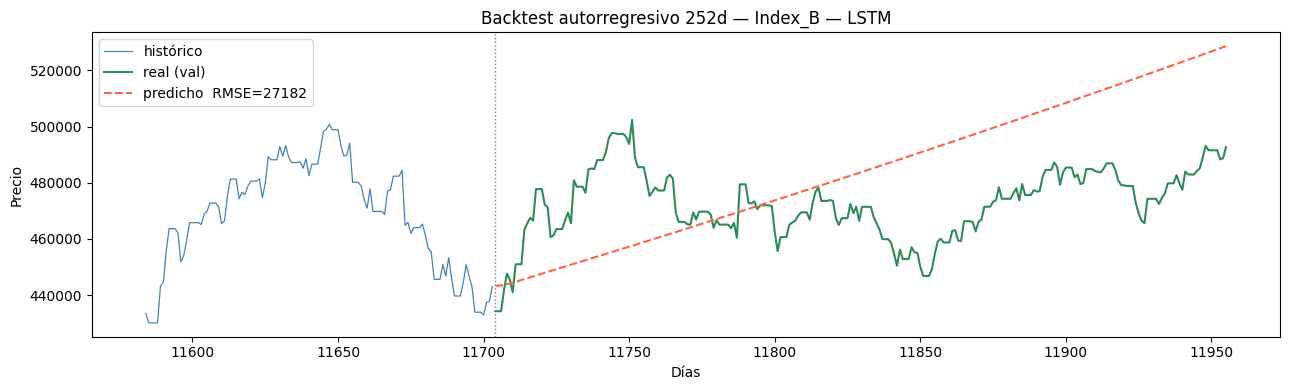

In [7]:
predict_fn_lstm = lambda x: model_lstm.predict(x, verbose=0).ravel()[0]
bt_lstm = backtest_autoregressive(predict_fn_lstm, serie, log_ret_mode=True)

print(f"LSTM      RMSE backtest = {bt_lstm['rmse']:,.0f}  |  dir_acc = {bt_lstm['dir_accuracy']:.2%}")
print(f"baseline  RMSE backtest = {best_rmse:,.0f}  ({best_bl})")
mejora = (best_rmse - bt_lstm['rmse']) / best_rmse
print(f"\n{'✓ LSTM MEJORA' if bt_lstm['rmse'] < best_rmse else '✗ LSTM NO mejora'} el baseline ({mejora:+.1%})")

plot_rollout(serie, bt_lstm['preds'], index_name=f"{IDX} — LSTM", val_days=VAL_DAYS)

## 5. [Opcional] Ensemble de semillas — solo si la LSTM ya gana

Si la LSTM batió al baseline, un ensemble de 3 seeds promedia varios modelos independientes y suele recortar la varianza, bajando un poco más el RMSE. Si la LSTM **no** ganó, esta celda se salta sola: no merece la pena gastar cómputo en un índice defensivo donde el baseline ya es mejor.

  [seed 0]  RMSE val (ventana) = 0.01
  [seed 1]  RMSE val (ventana) = 0.01
  [seed 2]  RMSE val (ventana) = 0.01

  Ensemble (3 seeds)  ->  val RMSE (ventana) = 0.01
  [!] Llamar backtest_autoregressive(result["predict_fn"], ...) para el RMSE real

Ensemble  RMSE backtest = 17,088  |  dir_acc = 34.26%


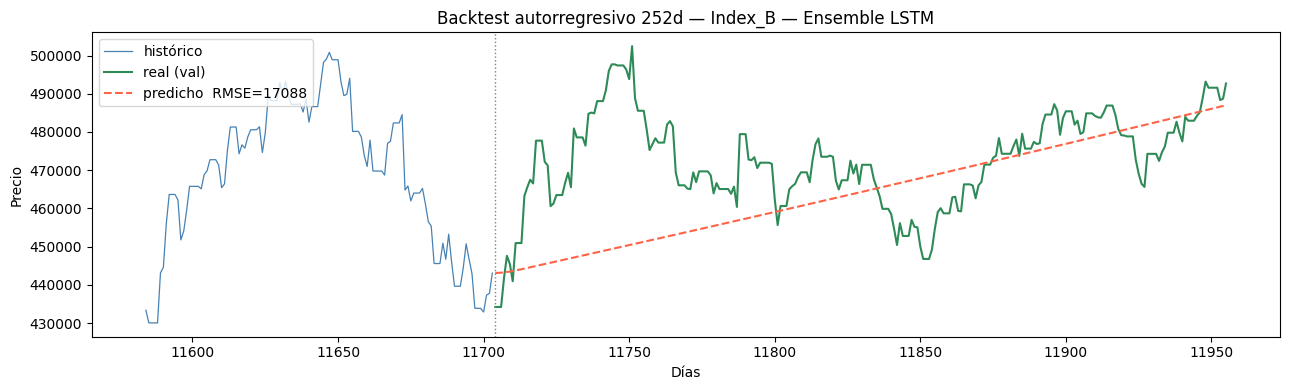

In [8]:
ens = None
if bt_lstm["rmse"] < best_rmse:
    ens = train_ensemble(
        "lstm", X_tr, y_tr, X_v, y_v,
        v_in=V_IN_SHARED, n_features=X.shape[2],
        n_seeds=3, epochs=300, dropout=0.2,
    )
    bt_ens = backtest_autoregressive(ens["predict_fn"], serie, log_ret_mode=True)
    print(f"\nEnsemble  RMSE backtest = {bt_ens['rmse']:,.0f}  |  dir_acc = {bt_ens['dir_accuracy']:.2%}")
    plot_rollout(serie, bt_ens["preds"], index_name=f"{IDX} — Ensemble LSTM", val_days=VAL_DAYS)
else:
    bt_ens = None
    print("LSTM no batió al baseline → se omite el ensemble. El baseline es la apuesta.")

## 6. Candidato alternativo — LSTM apilada + MAE

Hipótesis: el límite en B no es capacidad sino calibración del drift. Una LSTM de 2 capas con regularización fuerte y `loss='mae'` (menos sensible a días de ruido extremo que MSE) podría estimar un drift medio mejor calibrado. NO esperamos un salto grande: B tiene poca señal. Decide el backtest, no la teoría.

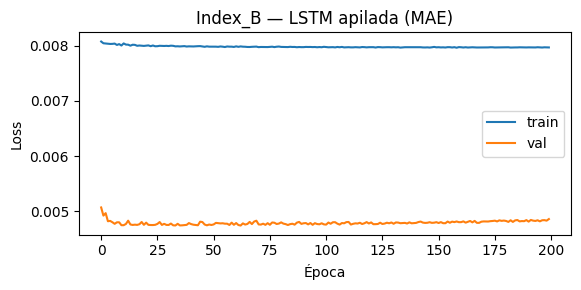

In [9]:
from keras import Sequential, Input
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import Adam

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

model_stack = Sequential([
    Input((V_IN_SHARED, X.shape[2])),
    LSTM(48, return_sequences=True),
    Dropout(0.3),
    LSTM(24),
    Dropout(0.3),
    Dense(1),
])
model_stack.compile(loss="mae", optimizer=Adam(learning_rate=3e-4))  # mae: robusto a outliers

hist_stack = train_model(model_stack, X_tr, y_tr, X_v, y_v, epochs=200)
plot_history(hist_stack, title=f"{IDX} — LSTM apilada (MAE)")

### 6.1 Backtest de la LSTM apilada

Comparamos contra la LSTM simple (27.182) y el baseline. Si no baja de 27.182, la conclusión legítima es que B está en su techo y nos quedamos con la LSTM simple.

LSTM apilada  RMSE backtest = 24,505  |  dir_acc = 33.86%
LSTM simple   RMSE backtest = 27,182
baseline      RMSE backtest = 31,852

Mejor NN: apilada (24,505)


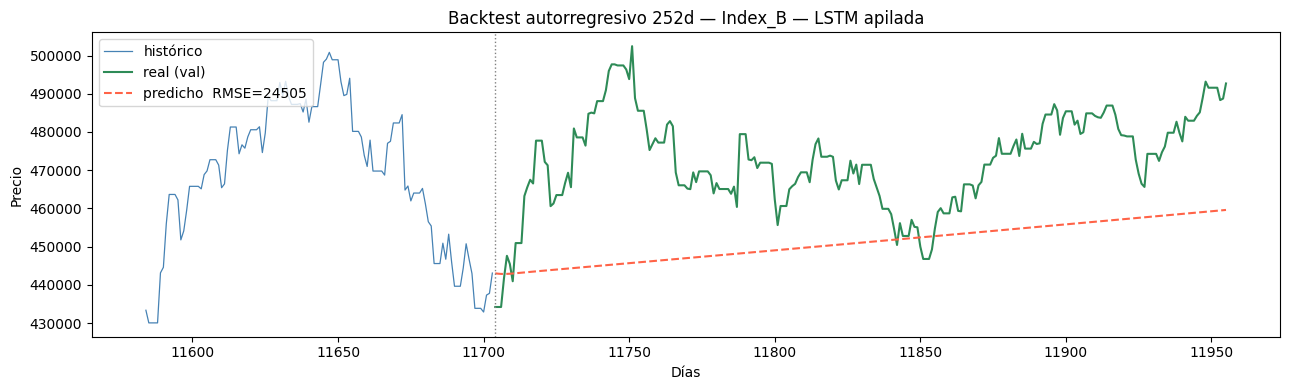

In [10]:
predict_fn_stack = lambda x: model_stack.predict(x, verbose=0).ravel()[0]
bt_stack = backtest_autoregressive(predict_fn_stack, serie, log_ret_mode=True)

print(f"LSTM apilada  RMSE backtest = {bt_stack['rmse']:,.0f}  |  dir_acc = {bt_stack['dir_accuracy']:.2%}")
print(f"LSTM simple   RMSE backtest = {bt_lstm['rmse']:,.0f}")
print(f"baseline      RMSE backtest = {best_rmse:,.0f}")

mejor = min([("apilada", bt_stack['rmse']), ("simple", bt_lstm['rmse'])], key=lambda t: t[1])
print(f"\nMejor NN: {mejor[0]} ({mejor[1]:,.0f})")
plot_rollout(serie, bt_stack['preds'], index_name=f"{IDX} — LSTM apilada", val_days=VAL_DAYS)

## 7. Decisión final y guardado

Elegimos el menor RMSE de backtest entre {baseline, LSTM, ensemble}. Solo guardamos un `.keras` si gana una NN; si gana el baseline, `model_path = None` y el notebook 09 lo reconstruye con la función de baseline correspondiente. El JSON sigue el mismo esquema que los demás índices para que la consolidación lo recoja sin tocar nada.

In [12]:
# Candidatos disponibles (el baseline siempre; NN/ensemble si se ejecutaron)
candidatos = {f"baseline_{best_bl}": best_rmse, "lstm": bt_lstm["rmse"]}
if ens is not None:
    candidatos["ensemble"] = bt_ens["rmse"]

print("Comparativa final (RMSE backtest 252d):")
for k, v in sorted(candidatos.items(), key=lambda kv: kv[1]):
    print(f"  {k:<20} {v:,.0f}")

ganador = min(candidatos, key=candidatos.get)
print(f"\nGanador: {ganador}")

# ── Construir el JSON según el ganador ──────────────────────────────────────────
_tipo_map = {"flat": "baseline_flat", "drift": "baseline_drift", "random_walk": "baseline_rw"}

if ganador.startswith("baseline"):
    info = {
        "index": IDX, "owner": OWNER,
        "approach_type": _tipo_map[best_bl], "strategy": best_bl,
        "rmse_backtest_252d": float(best_rmse),
        "model_path": None, "log_ret_mode": False,
        "v_in": None, "n_features": 1,
        "aux_source": None, "aux_test_source": None, "aux_columns": None,
        "ghost_source_index": None, "ghost_lag": None,
        "notes": f"Baseline {best_bl} gana — serie defensiva, NN no aporta en backtest 252d.",
    }
else:
    # Gana una NN: guardar el modelo (si ensemble, el primer seed como representante)
    if ganador == "ensemble":
        ens["models"][0].save(MODEL_PATH)
        approach, strategy, rmse_win = "nn_ensemble", "lstm", bt_ens["rmse"]
        note = "Ensemble 3-seed LSTM (log-ret) batió al baseline en backtest 252d."
    else:
        model_lstm.save(MODEL_PATH)
        approach, strategy, rmse_win = "nn", "lstm", bt_lstm["rmse"]
        note = "LSTM (log-ret, dropout=0.2) batió al baseline en backtest 252d."
    info = {
        "index": IDX, "owner": OWNER,
        "approach_type": approach, "strategy": strategy,
        "rmse_backtest_252d": float(rmse_win),
        "model_path": MODEL_PATH, "log_ret_mode": True,
        "v_in": V_IN_SHARED, "n_features": int(X.shape[2]),
        "aux_source": None, "aux_test_source": None, "aux_columns": None,
        "ghost_source_index": None, "ghost_lag": None,
        "notes": note,
    }
    print("Guardado modelo:", MODEL_PATH)

with open("results/index_B.json", "w") as f:
    json.dump(info, f, indent=2)

print("Guardado: results/index_B.json")
print(json.dumps(info, indent=2))

Comparativa final (RMSE backtest 252d):
  ensemble             17,088
  lstm                 27,182
  baseline_flat        31,852

Ganador: ensemble
Guardado modelo: models/dani_Index_B.keras
Guardado: results/index_B.json
{
  "index": "Index_B",
  "owner": "dani",
  "approach_type": "nn_ensemble",
  "strategy": "lstm",
  "rmse_backtest_252d": 17088.154911024078,
  "model_path": "models/dani_Index_B.keras",
  "log_ret_mode": true,
  "v_in": 20,
  "n_features": 1,
  "aux_source": null,
  "aux_test_source": null,
  "aux_columns": null,
  "ghost_source_index": null,
  "ghost_lag": null,
  "notes": "Ensemble 3-seed LSTM (log-ret) bati\u00f3 al baseline en backtest 252d."
}


## 8. Generación de predicciones de producción para los 252 días futuros

Para la entrega, hacemos un rollout nuevo usando la serie COMPLETA (todos los días históricos) como contexto, sin reservar los últimos 252 como validación. Esto genera las predicciones para los 252 días del futuro real.

In [13]:
from utils import precios_a_logret, predict_autoregressive

# Usar el modelo ganador (el que guardamos en results/index_B.json)
# Si gana el ensemble, usamos ens['predict_fn']. Si gana el baseline, no hay modelo.
# Por eso verificamos primero:

if ganador == "ensemble":
    predict_fn_prod = ens['predict_fn']
    print("Usando ensemble ganador para predicciones de producción")
elif ganador == "lstm":
    predict_fn_prod = predict_fn_lstm
    print("Usando LSTM simple ganadora para predicciones de producción")
elif ganador.startswith("baseline"):
    print(f"Ganador es baseline {best_bl} → no hay modelo, usar baseline_fn")
    # Recrear la función del baseline
    if best_bl == "flat":
        predict_fn_prod = lambda x: baseline_flat(serie[-V_IN_SHARED:], 1)[0]  # muy simplificado
    # (en producción esto lo hace el notebook 09)
    print("⚠️ Para baseline: el notebook 09 se encarga de generar las predicciones.")
else:
    predict_fn_prod = predict_fn_lstm  # fallback
    print("Fallback: usando LSTM simple")

# ── Rollout de producción (252 días futuros) ──────────────────────────────────
# Ventana inicial: últimos V_IN_SHARED log-retornos de la serie COMPLETA
log_rets_full = precios_a_logret(serie)   # (T-1,)
ventana_prod = np.zeros((V_IN_SHARED, 1), dtype=np.float32)
ventana_prod[:, 0] = log_rets_full[-V_IN_SHARED:]

# Punto de anclaje: último precio real conocido
precio_inicial = float(serie[-1])

print(f"\nGenerando predicciones para 252 días:")
print(f"  Ventana inicial: últimos {V_IN_SHARED} log-rets")
print(f"  Precio inicial (ancla): {precio_inicial:,.0f}")

# Rollout: modelo predice log-rets, predict_autoregressive reconstruye precios
preds_produccion = predict_autoregressive(
    predict_fn_prod,
    ventana_prod,
    252,
    precio_inicial=precio_inicial,
    aux_data=None,
    clip_logret=0.5
)

print(f"Predicciones generadas: {len(preds_produccion)} valores")
print(f"  min={preds_produccion.min():,.0f}  max={preds_produccion.max():,.0f}")
print(f"  primeros 5: {preds_produccion[:5]}")

Usando ensemble ganador para predicciones de producción

Generando predicciones para 252 días:
  Ventana inicial: últimos 20 log-rets
  Precio inicial (ancla): 492,687
Predicciones generadas: 252 valores
  min=492,836  max=542,090
  primeros 5: [492835.83628625 492981.05738613 493131.47548964 493289.61407456
 493456.8668504 ]


## 9. Guardar predicciones en Excel/CSV para el compañero

Las predicciones ahora están en `preds_produccion`. Las guardamos en un Excel o CSV con las fechas del test para que el compañero las meta directamente en la plantilla de entrega.

In [16]:
# Cargar las fechas del test (si existen)
test_dates = data.get('test_dates')

if test_dates is not None:
    fechas = test_dates.index
else:
    # Si no hay test_dates.csv, generar fechas manualmente a partir del último día histórico
    import pandas as pd
    from datetime import timedelta
    
    ultimo_dia = idx.index[-1]
    fechas_aprox = pd.date_range(start=ultimo_dia + timedelta(days=1), periods=252, freq='D')
    print(f"⚠️ Generadas fechas aproximadas (idealmente usar test_dates.csv)")
    fechas = fechas_aprox

# Crear DataFrame con fechas y predicciones
df_submission = pd.DataFrame({
    'Date': fechas,
    f'pred_{IDX}': preds_produccion
})

# Guardar en CSV (sin Excel)
csv_path = f'results/{OWNER}_{IDX}_predicciones_252d.csv'
df_submission.to_csv(csv_path, index=False)
print(f"Guardado: {csv_path}")

# Mostrar las primeras filas
print(f"\n{IDX} — Predicciones de producción:")
print(df_submission.head(10))

⚠️ Generadas fechas aproximadas (idealmente usar test_dates.csv)
Guardado: results/dani_Index_B_predicciones_252d.csv

Index_B — Predicciones de producción:
        Date   pred_Index_B
0 2028-12-13  492835.836286
1 2028-12-14  492981.057386
2 2028-12-15  493131.475490
3 2028-12-16  493289.614075
4 2028-12-17  493456.866850
5 2028-12-18  493631.729905
6 2028-12-19  493810.613170
7 2028-12-20  493993.836463
8 2028-12-21  494179.846043
9 2028-12-22  494367.654348
